# Matplotlib Intro Demo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

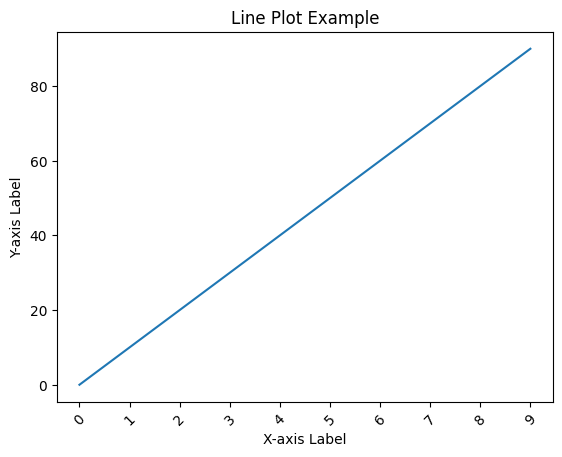

In [ ]:
data = [x * 10 for x in range(10)]
labels = [f'{x}' for x in range(10)]

plt.plot(labels, data) #first way

plt.title('Line Plot Example')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
# plt.xticks(rotation=45)ß

plt.show()

In [4]:
df = pd.DataFrame(data, labels).assign(series2 = lambda x: x[0] /2)

df.head()

,0,series2
0,0,0.0
1,10,5.0
2,20,10.0
3,30,15.0
4,40,20.0


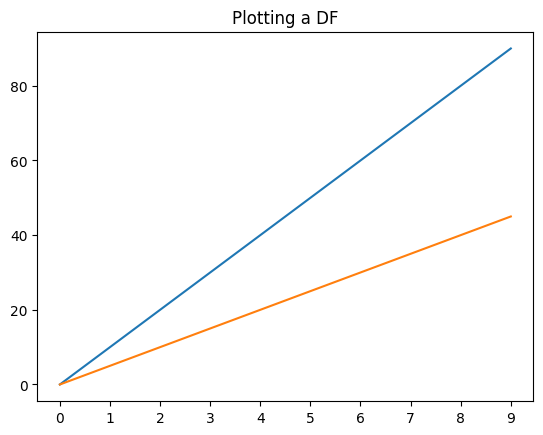

In [5]:
plt.plot(df)

plt.title("Plotting a DF")

plt.show()

# Object Oriented Plotting

Text(0.5, 0.98, 'Overall Title')

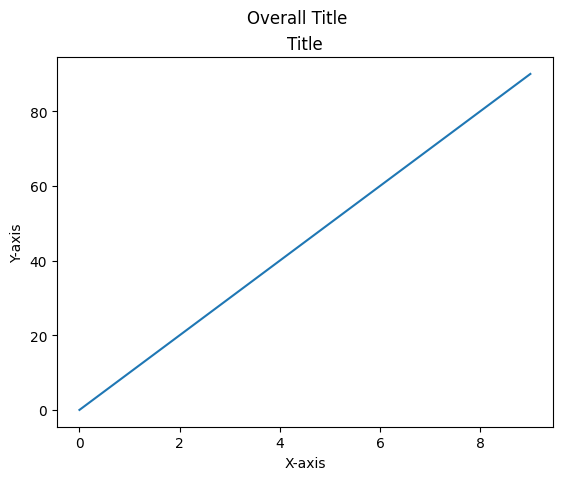

In [9]:
import matplotlib.pyplot as plt
# figure, axis
# figure: outer side change
# axis: inner side change

fig, ax = plt.subplots() # objects OP


ax.plot(data)
ax.set_title("Title")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
fig.suptitle("Overall Title")

# Plotting DataFrames

# Formatted Line Chart Demo

In [10]:
housing_raw = pd.read_csv(
    "housing_data.csv",
    parse_dates=["period_begin", "period_end"],
    dtype={"total_homes_sold": "Int32", "region_name": "category"}
)

ca_housing = (
    housing_raw
    .loc[(housing_raw["region_name"].str.contains("CA"))]
    .assign(region_name = housing_raw["region_name"].str[0:-11])
)

ca_housing_pivot = (
    ca_housing
    .pivot_table(
        index="period_begin",
        columns = "region_name",
        values = "median_active_list_price"
    )
    .assign(CA_average = lambda x: x.mean(axis=1))
)

ca_housing_markets = ca_housing_pivot.loc[:, ["San Francisco",
                                              "Los Angeles",
                                              "San Diego",
                                              "Tulare"]]

ca_housing_markets.head()

region_name,San Francisco,Los Angeles,San Diego,Tulare
period_begin,,,,
2017-01-02,1229018.7,611561.0,618570.8,225395.8
2017-01-09,1233393.7,614061.0,621737.5,227729.1
2017-01-16,1239977.0,617311.0,625820.8,229060.4
2017-01-23,1247977.0,620644.3,629491.6,229806.2
2017-01-30,1253310.4,624541.6,632824.0,230139.5


# Stacked Line Chart

In [ ]:
ca_housing.head()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
6,Sacramento,2020-06-22,2020-09-13,5107,1729.0,2206.0,27.5,445540.9,5.235794
164,Nevada,2018-09-03,2018-11-25,529,480.0,517.0,71.4,557508.3,12.165607
252,Stanislaus,2017-06-05,2017-08-27,1572,1042.0,1193.0,38.8,320660.0,9.212632
293,Tehama,2020-01-20,2020-04-12,102,241.0,252.0,99.2,297979.1,31.530228
304,Stanislaus,2017-11-13,2018-02-04,1200,797.0,907.0,56.5,330049.9,9.744362


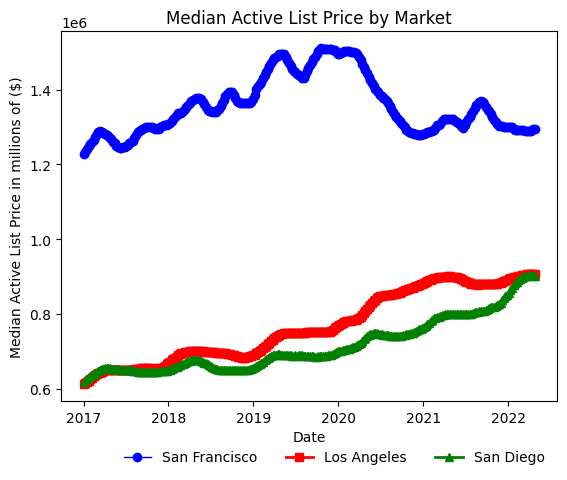

In [45]:
# line chart
fig, ax = plt.subplots() #advanced way with customization

ax.plot(ca_housing_markets["San Francisco"], label="San Francisco", linewidth=1, color='blue', marker='o')  # line plots
ax.plot(ca_housing_markets["Los Angeles"], label="Los Angeles", linewidth=2, color='red', marker='s')
ax.plot(ca_housing_markets["San Diego"], label="San Diego", linewidth=2, color='green', marker='^')

# ax.legend(['San Francisco', 'Los Angeles', 'San Diego'])  # legend, if label is defined in plot, no need to define here
# ax.legend(loc='upper right')  # legend if label is defined in plot, no need to define here

ax.legend(bbox_to_anchor=(1, -0.1), ncol=3, frameon=False)  # legend if label is defined in plot, no need to define here

ax.set_title("Median Active List Price by Market")
ax.set_xlabel("Date")
ax.set_ylabel("Median Active List Price in millions of ($)")
plt.show()

# Bar Charts

<BarContainer object of 5 artists>

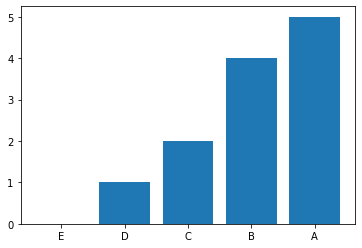

In [ ]:
fig, ax = plt.subplots()

labels = ["E", "D", "C", "B", "A"]
data = [0, 1, 2, 4, 5]
ax.bar(labels, data)

<BarContainer object of 5 artists>

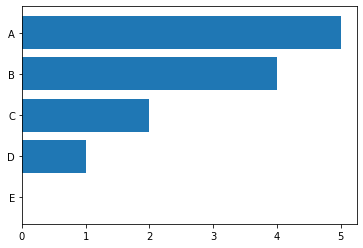

In [ ]:
fig, ax = plt.subplots()

labels = ["E", "D", "C", "B", "A"]
data = [0, 1, 2, 4, 5]
ax.barh(labels, data)

In [ ]:
total_sold = (ca_housing
 .groupby("region_name")
 .agg({"total_homes_sold":"sum"})
 .sort_values("total_homes_sold", ascending=False)
 .iloc[:10])

total_sold

,total_homes_sold
region_name,
Los Angeles,4622703
San Diego,2373289
Riverside,2335243
Orange,2004799
San Bernardino,1705727
Sacramento,1256838
Santa Clara,967707
Alameda,925469
Contra Costa,921039


# Stacked Bar Charts

# Grouped Bar Charts

In [ ]:
ca_or

state,CA,OR,WA
price_range,,,
0-400k,4267.0,1074.0,2143.0
400k-600k,13877.0,4711.0,4858.0
600k+,35147.0,1229.0,3649.0


# Pie Charts

In [ ]:
sales_totals = (
    ca_housing
    .query("region_name in ['San Francisco', 'Los Angeles', 'San Diego']")
    .groupby("region_name")
    .agg({"total_homes_sold":"sum"})
)

sales_totals.head()

,total_homes_sold
region_name,
Los Angeles,4622703
San Diego,2373289
San Francisco,371776


Text(0.5, 1.0, 'Share of Home Sales Select CA Markets')

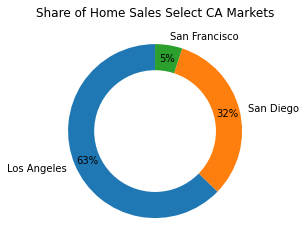

In [ ]:
fig, ax = plt.subplots()


hole = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(hole)

ax.set_title("Share of Home Sales Select CA Markets")

# Histograms

In [ ]:
diamonds = pd.read_csv("../data/Diamonds Prices2022.csv")